In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_data_reader.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'
from barplot_brackets import *

# LOAD METRICS


In [2]:
# Load Dutta Data
results_path = os.path.join("spikes", "all_networks_metrics_dutta.csv")

if os.path.exists(results_path):
    dutta_df = pd.read_csv(results_path)
    print(f"Loaded {len(dutta_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in dutta_df.columns:
        dutta_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", dutta_df.columns.tolist())
    print("Threshold:", sorted(dutta_df["Threshold"].unique()))
    
    display(dutta_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 162 rows from spikes\all_networks_metrics_dutta.csv
Columns: ['Session', 'Channel', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


,Session,Channel,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-24_17-38-17,13,3.0,11,564,4,0.019130,0.733333,0.037288,35.321212,577,15,10.479720
1,2025-09-24_16-29-07,5,3.0,25,497,15,0.047893,0.625000,0.088968,9.848000,528,40,10.618442
2,2025-09-22_17-55-26,26,3.0,130,251,55,0.341207,0.702703,0.459364,16.261795,385,185,10.399793
3,2025-09-23_15-50-26,28,3.0,94,333,45,0.220141,0.676259,0.332155,11.527305,430,139,10.387618
4,2025-09-24_10-24-40,30,3.0,57,502,35,0.101968,0.619565,0.175115,16.625731,564,92,10.413202


In [3]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplenet.csv")

if os.path.exists(results_path):
    rippleNet_df = pd.read_csv(results_path)
    print(f"Loaded {len(rippleNet_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in rippleNet_df.columns:
        rippleNet_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", rippleNet_df.columns.tolist())
    print("Threshold:", sorted(rippleNet_df["Threshold"].unique()))
    
    display(rippleNet_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2268 rows from spikes\all_networks_metrics_ripplenet.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed123,78,178,31,0.304688,0.715596,0.427397,35.347436,269,109,10.506607
1,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed456,78,158,31,0.330508,0.715596,0.452174,34.717949,244,109,10.506607
2,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed789,77,189,32,0.289474,0.706422,0.410667,30.353680,277,109,10.506607
3,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed123,66,99,43,0.400000,0.605505,0.481752,40.259091,171,109,10.506607
4,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed456,80,180,29,0.307692,0.733945,0.433604,32.437917,271,109,10.506607


In [4]:
# Load RipplAI Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    ripplAI_df = pd.read_csv(results_path)
    print(f"Loaded {len(ripplAI_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in ripplAI_df.columns:
        ripplAI_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
    
    ripplAI_df['Model'] = ripplAI_df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)

    print("Columns:", ripplAI_df.columns.tolist())
    print("Threshold:", sorted(ripplAI_df["Threshold"].unique()))
    
    display(ripplAI_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 6050 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-22_17-42-27,24,0.1,CNN1D,96,256,13,0.272727,0.880734,0.416486,10.148958,421,109,10.506607
1,2025-09-22_17-42-27,24,0.1,CNN1D,61,17,48,0.782051,0.559633,0.652406,13.282514,82,109,10.506607
2,2025-09-22_17-42-27,24,0.1,CNN1D,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109,10.506607
3,2025-09-22_17-42-27,24,0.1,CNN1D,73,40,36,0.646018,0.669725,0.657658,9.045662,116,109,10.506607
4,2025-09-22_17-42-27,24,0.1,CNN1D,87,207,22,0.295918,0.798165,0.431762,7.213410,324,109,10.506607


In [5]:
# Load Data
results_path = os.path.join(os.pardir,"liset_test","cnn_detections", "all_networks_metrics_liset.csv")

if os.path.exists(results_path):
    liset_df = pd.read_csv(results_path)
    print(f"Loaded {len(liset_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in liset_df.columns:
        liset_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", liset_df.columns.tolist())
    print("Threshold:", sorted(liset_df["Threshold"].unique()))
    
    display(liset_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 216 rows from ..\liset_test\cnn_detections\all_networks_metrics_liset.csv
Columns: ['Session', 'Channel', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


,Session,Channel,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-24_14-22-55,25,0.3,259,37,5,0.875000,0.981061,0.925000,7.943758,1561,264,6.399817
1,2025-09-24_10-24-40,30,0.3,51,188,41,0.213389,0.554348,0.308157,22.577778,398,92,10.413202
2,2025-09-25_12-52-22,25,0.3,14,196,34,0.066667,0.291667,0.108527,45.276190,682,48,10.408512
3,2025-09-24_11-34-51,30,0.3,61,176,10,0.257384,0.859155,0.396104,18.681967,517,71,6.631565
4,2025-09-24_15-13-10,14,0.3,59,6,25,0.907692,0.702381,0.791946,21.240678,162,84,5.505123


In [6]:
# Load SNN Data
# Load Data
results_path = os.path.join(os.pardir,"snnTorch","generalization_madrid", "spikes", "all_networks_metrics.csv")

if os.path.exists(results_path):
    snn_df = pd.read_csv(results_path)
    print(f"Loaded {len(snn_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in snn_df.columns:
        snn_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", snn_df.columns.tolist())
    
    display(snn_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 1296 rows from ..\snnTorch\generalization_madrid\spikes\all_networks_metrics.csv
Columns: ['Session', 'Channel', 'Network', 'Adapt', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']


,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-24_11-34-51,30,adapt20_3b,120,25,16,46,0.609756,0.352113,0.446429,34.709333,152,71,6.631565
1,2025-09-23_15-50-26,28,adapt20_3b,120,133,114,6,0.538462,0.956835,0.689119,22.560652,2307,139,10.387618
2,2025-09-25_11-21-53,21,adapt20_3b,120,167,82,35,0.670683,0.826733,0.740576,24.250699,1689,202,10.375892
3,2025-09-24_15-13-10,14,adapt20_3b,120,84,52,0,0.617647,1.000000,0.763636,16.757540,1789,84,5.505123
4,2025-09-25_16-41-14,21,adapt20_3b,120,127,185,17,0.407051,0.881944,0.557018,24.292126,2903,144,10.424501


In [7]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

all_dfs=[dutta_df, rippleNet_df, ripplAI_df, liset_df, snn_df]

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

for df in all_dfs:    
    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

    df=df[~df["Session"].isin(sessions_to_reject)]
    print(df["Session"].unique())
    # df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-24_16-29-07' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-24_10-24-40' '2025-09-23_16-17-52' '2025-09-25_11-21-53'
 '2025-09-24_11-34-51' '2025-09-25_16-41-14' '2025-09-22_17-42-27'
 'PV01ai32FPGA_250611_122326' 'PV01ai32FPGA_250611_115923'
 'Calbai32FPGA_251003_150055' 'Calbai32FPGA_251003_144832'
 'Calb_251211_105518' 'Calb_251210_122327' 'Calb_251209_160255'
 'Calb_251210_162849' 'Calb_251210_164150' 'Calb_251210_121141'
 'Calb_251211_110650' 'Calb_251211_104316' 'Calb_251210_115904'
 'Calb_251210_165332']
['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-25_11-21-53' '2025-09-25_16-41-14'
 'Calbai32FPGA_251003_144832' 'Calbai32FPGA_251003_150055'
 'Calb_251209_160255' 'Calb_251210_115904' 'Calb_251210_121141'
 'Calb_251210_122327' 'Calb_251210_162849' 'Calb_251210_164150'
 'Calb_251210_165332' 'Calb_251211_104316' 'Calb_251211_105518'
 'Calb_251211_

In [8]:
# Give me total number of ripples (Num_Ripples per session)
total_ripples = 0
dutta_df_copy=dutta_df.copy()
snn_df_copy=snn_df.copy()
snn_df_copy=snn_df_copy[~snn_df_copy["Session"].isin(sessions_to_reject)]
dutta_df_copy=dutta_df_copy[~dutta_df_copy["Session"].isin(sessions_to_reject)]


for session in dutta_df_copy["Session"].unique():
    num_ripples_session = dutta_df_copy[dutta_df_copy["Session"]==session]["Num_Ripples"].values[0]
    total_ripples += num_ripples_session
print(f"Total ripples across all sessions (after rejection): {total_ripples}")


Total ripples across all sessions (after rejection): 2719


Number of sessions in Dutta : 23
Number of sessions in RippleNet : 23
Number of sessions in Liset : 23
Number of sessions in RipplAI (XGBOOST) : 23
Number of sessions in SNN : 23


SNN vs Dutta: p=0.0006
SNN vs RippleNet: p=0.0002


C:\Users\NCN\AppData\Local\Temp\ipykernel_30096\2696936304.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=order)


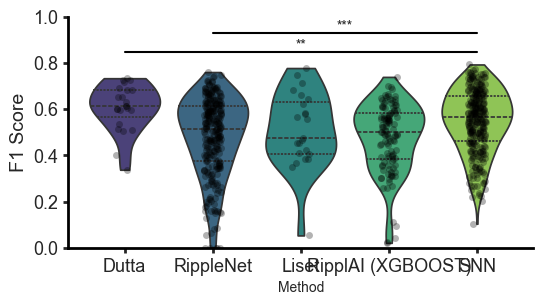

In [9]:
def plot_comparison_by_thresholds(config, metric="F1", reference_method="SNN", sessions_reject=None):
    """
    Plots metric distribution for specific thresholds across different dataframes.
    
    Args:
        config (dict): Dictionary where key is the label (str) and value is a tuple (DataFrame, threshold_value).
                       Example: {"Dutta": (dutta_df, 0.6), "SNN": (snn_df, 0.4)}
        metric (str): Metric to plot (default "F1").
        reference_method (str): Method to compare others against (default "SNN").
        sessions_reject (set/list): Optional set of session IDs to exclude.
    """
    combined_data = []
    
    for label, (df, threshold) in config.items():
        
        # Filter sessions if requested
        if sessions_reject is not None:
            df = df[~df["Session"].isin(sessions_reject)]
            
        print("Number of sessions in", label, ":", df["Session"].nunique())

        # Determine column name dynamically to avoid KeyError
        if "Threshold" in df.columns:
            col_name = "Threshold"
        elif "Adapt" in df.columns:
            col_name = "Adapt"
        else:
            print(f"Skipping {label}: Neither 'Threshold' nor 'Adapt' column found.")
            continue

        # Filter for the specific threshold
        subset = df[df[col_name] == threshold].copy()
        
        if len(subset) == 0:
            print(f"Warning: No data found for '{label}' at {col_name} {threshold}. Available: {sorted(df[col_name].unique())}")
            continue
            
        subset["Method"] = label
        combined_data.append(subset)
    
    if not combined_data:
        print("No data available to plot.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    # Plot setup
    fig, ax = plt.subplots(figsize=(6, 3))
    order = list(config.keys())
    # Filter order to only include those that had data
    order = [o for o in order if o in plot_df["Method"].unique()]
    
    colors = sns.color_palette("viridis", len(order))
    # colors=["#f6fff8","#eaf4f4","#cce3de","#a4c3b2","#6b9080"]
    # Violin plot
    sns.violinplot(x="Method", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=order)
    sns.stripplot(x="Method", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=order)
    
    # Statistics (Paired Wilcoxon)
    # Pivot to align samples by Session/Channel for paired testing
    pivot_cols = ["Session", "Channel"]
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Method", values=metric)
    
    # Annotate medians
    medians = plot_df.groupby('Method')[metric].median()
    mins = plot_df.groupby('Method')[metric].min()
    
    for i, method in enumerate(order):
        if method in medians:
            val = medians[method]
            min_val = mins[method]
            # Position text slightly below the minimum point
            # ax.text(i, min_val - 0.08, f'M={val:.2f}', ha='center', va='top', fontsize=11, color='black')

    # Statistical brackets - Only compare reference_method vs others
    if len(pivot) > 0 and reference_method in pivot.columns:
        centers = range(len(order))
        max_val = plot_df[metric].max()
        
        # Find index of reference method
        try:
            ref_idx = order.index(reference_method)
        except ValueError:
            print(f"Reference method {reference_method} not in plot order.")
            ref_idx = -1

        if ref_idx != -1:
            bracket_counter = 0
            
            # Iterate over other methods to compare against reference
            for i, method in enumerate(order):
                if method == reference_method:
                    continue
                
                if method not in pivot:
                    continue
        
                # Get paired data
                v1 = pivot[reference_method]
                v2 = pivot[method]
                
                # Align indices to ensure paired samples
                common = v1.index.intersection(v2.index)
                v1 = v1.loc[common]
                v2 = v2.loc[common]
                
                if len(v1) >= 3:
                    # Use Wilcoxon for paired samples (same session/channel)
                    stat, p = wilcoxon(v1, v2)
                    
                    if p < 0.05:
                        
                        # Stacking brackets
                        h = max_val + 0.01 + (bracket_counter * 0.08)
                        print(f"{reference_method} vs {method}: p={p:.4f}")
                        barplot_annotate_brackets(ref_idx, i, p, centers, [h]*len(centers), ax,barh=0,maxasterix=3)
                        bracket_counter += 1

    # Styling
    ax.set_ylim(0, 1.0) # Add space for brackets
    ax.set_ylabel(f"{metric} Score", fontsize=14)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)

# --- Example Usage ---
comparison_config = {
    "Dutta": (dutta_df, 6.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.5),
    "RipplAI (XGBOOST)": (ripplAI_df[ripplAI_df['Model']=='XGBOOST'], 0.6),
    "SNN": (snn_df,120)
}

if 'dutta_df' in locals():
    plot_comparison_by_thresholds(comparison_config, metric="F1", reference_method="SNN", sessions_reject=sessions_to_reject)

Number of sessions in Dutta : 23
Number of sessions in RippleNet : 23
Number of sessions in Liset : 23
Number of sessions in RipplAI (CNN1D) : 23
Number of sessions in SNN : 23
SNN vs Dutta: p=0.0000
SNN vs RippleNet: p=0.0003
SNN vs RipplAI (CNN1D): p=0.0277


C:\Users\NCN\AppData\Local\Temp\ipykernel_30096\2696936304.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=order)


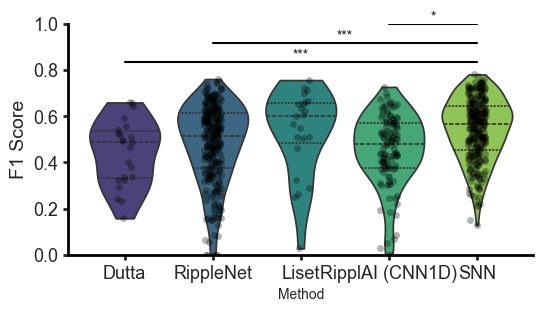

In [10]:
# Default Parameters

comparison_config = {
    "Dutta": (dutta_df, 4.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.7),
    "RipplAI (CNN1D)": (ripplAI_df[ripplAI_df['Model']=='CNN1D'], 0.3),
    "SNN": (snn_df,20)
}

if 'dutta_df' in locals():
    plot_comparison_by_thresholds(comparison_config, metric="F1", reference_method="SNN", sessions_reject=sessions_to_reject)

C:\Users\NCN\AppData\Local\Temp\ipykernel_30096\1679516678.py:69: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="Method", y=metric, hue="Type", data=other_methods_df, split=True,
C:\Users\NCN\AppData\Local\Temp\ipykernel_30096\1679516678.py:82: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="Method", y=metric,


[Optimized] SNN vs RippleNet: p=0.0123
[Optimized] SNN vs RipplAI: p=0.0135
[Standard] SNN vs Dutta: p=0.0000
[Standard] SNN vs RippleNet: p=0.0011
[Within Dutta] Optimized vs Standard: p=0.0000
[Within Liset] Optimized vs Standard: No difference (all values identical)


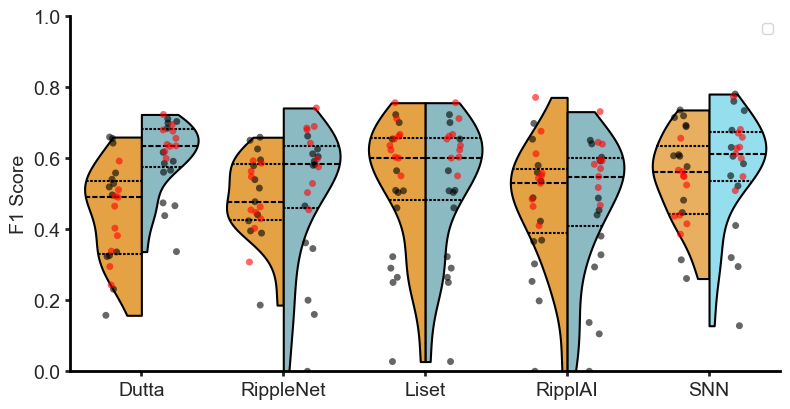

In [11]:
def plot_comparison_split_violin(config_opt, config_std, metric="F1", reference_method="SNN", sessions_reject=None,aggregate=False):
    """
    Plots split violins comparing two configurations (e.g. Optimized vs Standard).
    """
    combined_data = []

    new_sess=["Calb_251209_160255",
    "Calb_251210_115904",
    "Calb_251210_121141",
    "Calb_251210_122327",
    "Calb_251210_162849",
    "Calb_251210_164150",
    "Calb_251210_165332",
    "Calb_251211_104316",
    "Calb_251211_105518",
    "Calb_251211_110650"]

    def process_config(config, type_label,aggregate=False):
        for label, (df, threshold) in config.items():
            # Filter sessions
            if sessions_reject is not None:
                df_subset = df[~df["Session"].isin(sessions_reject)].copy()
            else:
                df_subset = df.copy()

            # Identify column
            if "Threshold" in df_subset.columns:
                col = "Threshold"
            elif "Adapt" in df_subset.columns:
                col = "Adapt"
            else:
                print(f"Skipping {label}: Column not found.")
                continue
                
            # Filter threshold
            subset = df_subset[df_subset[col] == threshold].copy()
            if aggregate:
                subset = subset.groupby(["Session", "Channel"])[metric].median().reset_index()
            if len(subset) > 0:
                subset["Method"] = label
                subset["Type"] = type_label
                combined_data.append(subset)
            else:
                print(f"Warning: No data for {label} ({type_label}) at {threshold}")

            subset["SessionType"]=subset["Session"].apply(lambda x: "New" if x in new_sess else "Old")

    process_config(config_opt, "Optimized", aggregate=aggregate)
    process_config(config_std, "Standard", aggregate=aggregate)
    
    if not combined_data:
        print("No data to plot.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(8, 4.2))
    
    # Determine order based on Optimized config keys
    order = [k for k in config_opt.keys() if k in plot_df["Method"].unique()]
    palette={"Optimized": "#82C0CC", "Standard": "#FFA62B"}
    
    # --- Split Plotting for SNN ---
    # Plot everything EXCEPT SNN first
    other_methods_df = plot_df[plot_df["Method"] != "SNN"]
    
    # scale="width" ensures both sides of the split violin have the same maximum width, 
    # preventing one side from being very thin if it has high variance (low density).
    sns.violinplot(x="Method", y=metric, hue="Type", data=other_methods_df, split=True, 
                   inner="quart", linewidth=1.5, palette=palette, 
                   ax=ax, order=order, cut=0, linecolor='black',hue_order=["Standard","Optimized"],
                   scale="width") 
    
    # Plot SNN separately with a single color
    snn_df_plot = plot_df[plot_df["Method"] == "SNN"]
    if not snn_df_plot.empty:
        # Use a distinct color for SNN (e.g., purple or grey)
        snn_color = "#9370DB" 
        # snn_palette = {"Optimized": snn_color, "Standard": snn_color}
        snn_palette={"Optimized": "#87E8FB", "Standard": "#FFB349"}

        sns.violinplot(x="Method", y=metric, 
                       hue="Type", 
                       data=snn_df_plot, split=True, 
                       inner="quart", linewidth=1.5, palette=snn_palette, 
                       ax=ax, order=order, cut=0, linecolor='black',hue_order=["Standard","Optimized"],
                       scale="width")
        
        # Prepare points data: Exclude 'Standard' for SNN
        stripplot_df = plot_df[~((plot_df["Method"] == "SNN"))]

        # Plot OLD sessions (Black)
        # For non-SNN methods
        sns.stripplot(x="Method",
                    y=metric, 
                    hue="Type", 
                    data=stripplot_df[stripplot_df["SessionType"]=="Old"], 
                    palette={"Standard": "black", "Optimized": "black"},
                    alpha=0.6, 
                    jitter=True, 
                    dodge=True, 
                    ax=ax,
                    legend=False,
                    hue_order=["Standard","Optimized"], 
                    order=order)
        
        # Plot NEW sessions (Red)
        # For non-SNN methods
        sns.stripplot(x="Method",
                    y=metric, 
                    hue="Type", 
                    data=stripplot_df[stripplot_df["SessionType"]=="New"], 
                    palette={"Standard": "red", "Optimized": "red"}, # RED for New
                    alpha=0.6, 
                    jitter=True, 
                    dodge=True, 
                    ax=ax,
                    legend=False, # Avoid duplicated legend entries
                    hue_order=["Standard","Optimized"], 
                    order=order)
        
        # Plot SNN points
        
        # Standard - Old (force Black)
        sns.stripplot(x="Method", y=metric, 
                     hue="Type", 
                     data=snn_df_plot[(snn_df_plot["SessionType"]=="Old")],
                     palette={"Standard": "black", "Optimized": "black"},
                     alpha=0.6, jitter=True, dodge=True, 
                     hue_order=["Standard","Optimized"],
                     ax=ax, legend=False, order=order)
                     
        # Standard - New (force Red)
        sns.stripplot(x="Method", y=metric, 
                     hue="Type", 
                     data=snn_df_plot[(snn_df_plot["SessionType"]=="New")],
                     palette={"Standard": "red", "Optimized": "red"},
                     alpha=0.6, jitter=True, dodge=True, 
                     hue_order=["Standard","Optimized"],
                     ax=ax, legend=False, order=order)


    # --- Statistics (Reference vs Others) ---
    # Compare both Optimized and Standard sets
    opt_df = plot_df[plot_df["Type"] == "Optimized"]
    pivot_opt = opt_df.pivot_table(index=["Session", "Channel"], columns="Method", values=metric) # averages by session/channel
    
    std_df = plot_df[plot_df["Type"] == "Standard"]
    pivot_std = std_df.pivot_table(index=["Session", "Channel"], columns="Method", values=metric) # averages by session/channel
    
    pivots = [pivot_opt, pivot_std]
    labels = ["Optimized", "Standard"]
    
    try:
        ref_idx = order.index(reference_method)
    except ValueError:
        ref_idx = -1

    if ref_idx != -1:
        for type_idx, piv in enumerate(pivots):
            if reference_method not in piv.columns:
                continue
                
            current_label = labels[type_idx]
            
            for method in order:
                if method == reference_method or method not in piv.columns:
                    continue
                
                # Paired Wilcoxon
                v1 = piv[reference_method]
                v2 = piv[method]

                common = v1.index.intersection(v2.index)
                v1, v2 = v1.loc[common], v2.loc[common]
                
                if len(v1) >= 3:
                    stat, p = wilcoxon(v1, v2)
                    if p < 0.05:
                        print(f"[{current_label}] {reference_method} vs {method}: p={p:.4f}")

    # --- Statistics (Optimized vs Standard within each Method) ---
    for method in order:
        opt_m = opt_df[opt_df["Method"] == method]
        std_m = std_df[std_df["Method"] == method]

        if opt_m.empty or std_m.empty:
            continue

        pivot_opt_m = opt_m.pivot_table(index=["Session", "Channel"], values=metric)
        pivot_std_m = std_m.pivot_table(index=["Session", "Channel"], values=metric)

        common = pivot_opt_m.index.intersection(pivot_std_m.index)
        v1 = pivot_opt_m.loc[common, metric]
        v2 = pivot_std_m.loc[common, metric]
        if (v1==v2).all():
            print(f"[Within {method}] Optimized vs Standard: No difference (all values identical)")
            continue
           

        if len(v1) >= 3:
            stat, p = wilcoxon(v1, v2)
            if p < 0.05:
                print(f"[Within {method}] Optimized vs Standard: p={p:.4f}")

    ax.set_ylim(0, 1)
    ax.set_ylabel(f"{metric} Score", fontsize=14)
    ax.set_xlabel("")
    # ax.legend(title="Parameters", loc='upper left', bbox_to_anchor=(1, 1))
    ax.legend("")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2.0)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=14, bottom=True, left=True,width=2.0)
    
    plt.tight_layout()
    plt.show()

    return fig,ax
# --- Configuration ---

# 1. Optimized Parameters
config_opt = {
    "Dutta": (dutta_df, 7.0),
    "RippleNet": (rippleNet_df[rippleNet_df["Model"]=="ripplenet_unidirectional_best_random_seed456"], 0.7),
    "Liset": (liset_df, 0.7), # Bad Recall
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='LSTM'], 0.5), # Renamed key to match
    # "SNN": (snn_df, 20)
    "SNN": (snn_df[snn_df["Network"]=="dsb4updn_median_200_12b"], 20) # best performing network...
}

# 2. Standard/Default Parameters
config_std = {
    "Dutta": (dutta_df, 4.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.7),
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='LSTM'], 0.4),   # Renamed key to match 
    "SNN": (snn_df, 20)
}
aggregate=True
if 'dutta_df' in locals():
    fig,ax=plot_comparison_split_violin(config_opt, config_std, metric="F1", reference_method="SNN", sessions_reject=sessions_to_reject,aggregate=aggregate )
    # fig.savefig("figures/comparison_optimized_vs_standard.svg", bbox_inches='tight')

In [12]:
def get_summary_table(config_opt, config_std, sessions_reject=None,aggregate=False):
    summary_data = []
    
    # List of metrics to check for in the dataframes
    metrics = ["F1", "Precision", "Recall"] 
    
    def process_config(config, type_label, aggregate=False):
        for label, (df, threshold) in config.items():
            # Filter sessions
            if sessions_reject is not None:
                df_subset = df[~df["Session"].isin(sessions_reject)].copy()
            else:
                df_subset = df.copy()

            # Identify column for threshold
            if "Threshold" in df_subset.columns:
                col = "Threshold"
            elif "Adapt" in df_subset.columns:
                col = "Adapt"
            else:
                continue
                
            # Filter threshold
            subset = df_subset[df_subset[col] == threshold].copy()
            if aggregate:
                subset = subset.groupby(["Session", "Channel"])[metrics].median().reset_index()
            if len(subset) > 0:
                row = {
                    "Method": label,
                    "Type": type_label,
                    "Threshold": threshold
                }
                
                for m in metrics:
                    if m in subset.columns:
                        mean_val = subset[m].median()
                        std_val = subset[m].std()
                        # Format as Mean ± Std
                        row[f"{m}"] = f"{mean_val:.2f} ± {std_val:.2f}"
                    else:
                        row[f"{m}"] = "N/A"
                
                summary_data.append(row)
    process_config(config_std, "Standard",aggregate=aggregate)
    process_config(config_opt, "Optimized",aggregate=aggregate)
    
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

# Generate and display the table
if 'dutta_df' in locals() and 'config_opt' in locals():
    summary_table = get_summary_table(config_opt, config_std, sessions_reject=sessions_to_reject,aggregate=aggregate)
    print("Performance Summary Table:")
    display(summary_table)

Performance Summary Table:


,Method,Type,Threshold,F1,Precision,Recall
0,Dutta,Standard,4.0,0.49 ± 0.14,0.35 ± 0.15,0.75 ± 0.08
1,RippleNet,Standard,0.7,0.48 ± 0.11,0.52 ± 0.18,0.71 ± 0.19
2,Liset,Standard,0.7,0.60 ± 0.19,0.58 ± 0.21,0.63 ± 0.25
3,RipplAI,Standard,0.4,0.53 ± 0.18,0.51 ± 0.25,0.70 ± 0.25
4,SNN,Standard,20.0,0.56 ± 0.13,0.50 ± 0.16,0.89 ± 0.19
5,Dutta,Optimized,7.0,0.63 ± 0.10,0.71 ± 0.15,0.57 ± 0.12
6,RippleNet,Optimized,0.7,0.58 ± 0.19,0.77 ± 0.24,0.49 ± 0.24
7,Liset,Optimized,0.7,0.60 ± 0.19,0.58 ± 0.21,0.63 ± 0.25
8,RipplAI,Optimized,0.5,0.55 ± 0.19,0.62 ± 0.25,0.59 ± 0.25
9,SNN,Optimized,20.0,0.61 ± 0.16,0.61 ± 0.15,0.70 ± 0.23


--- Statistics for F1 vs Ripples/min ---
Dutta: Slope=0.0010, Pearson r=0.045, p=0.8386;  Spearman ρ=0.003, p=0.9893
RippleNet: Slope=0.0032, Pearson r=0.077, p=0.7258;  Spearman ρ=0.024, p=0.9145
Liset: Slope=0.0039, Pearson r=0.094, p=0.6701;  Spearman ρ=0.048, p=0.8263
RipplAI: Slope=0.0024, Pearson r=0.056, p=0.7983;  Spearman ρ=0.040, p=0.8579
SNN: Slope=0.0137, Pearson r=0.383, p=0.0711;  Spearman ρ=0.448, p=0.0322


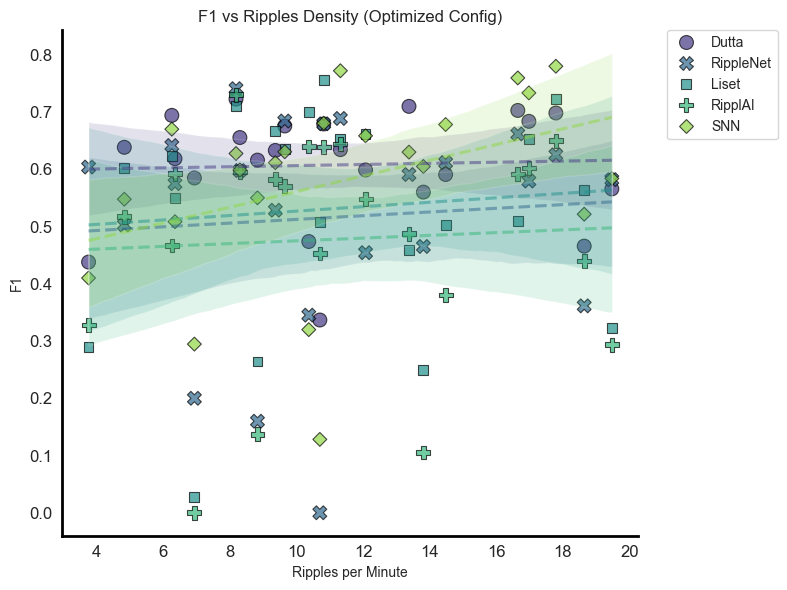

--- Statistics for Precision vs Ripples/min ---
Dutta: Slope=0.0282, Pearson r=0.845, p=0.0000;  Spearman ρ=0.865, p=0.0000
RippleNet: Slope=0.0192, Pearson r=0.354, p=0.0980;  Spearman ρ=0.362, p=0.0894
Liset: Slope=0.0071, Pearson r=0.154, p=0.4840;  Spearman ρ=0.165, p=0.4518
RipplAI: Slope=0.0124, Pearson r=0.222, p=0.3096;  Spearman ρ=0.203, p=0.3539
SNN: Slope=0.0288, Pearson r=0.866, p=0.0000;  Spearman ρ=0.842, p=0.0000


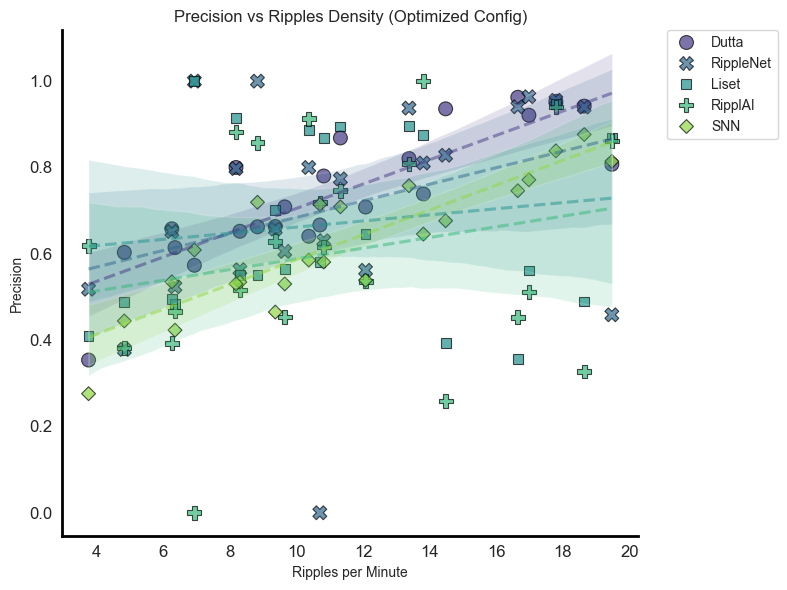

--- Statistics for Recall vs Ripples/min ---
Dutta: Slope=-0.0144, Pearson r=-0.522, p=0.0106;  Spearman ρ=-0.659, p=0.0006
RippleNet: Slope=-0.0087, Pearson r=-0.165, p=0.4516;  Spearman ρ=-0.218, p=0.3168
Liset: Slope=0.0040, Pearson r=0.074, p=0.7370;  Spearman ρ=0.040, p=0.8579
RipplAI: Slope=0.0010, Pearson r=0.018, p=0.9352;  Spearman ρ=-0.071, p=0.7470
SNN: Slope=-0.0070, Pearson r=-0.134, p=0.5431;  Spearman ρ=-0.198, p=0.3660


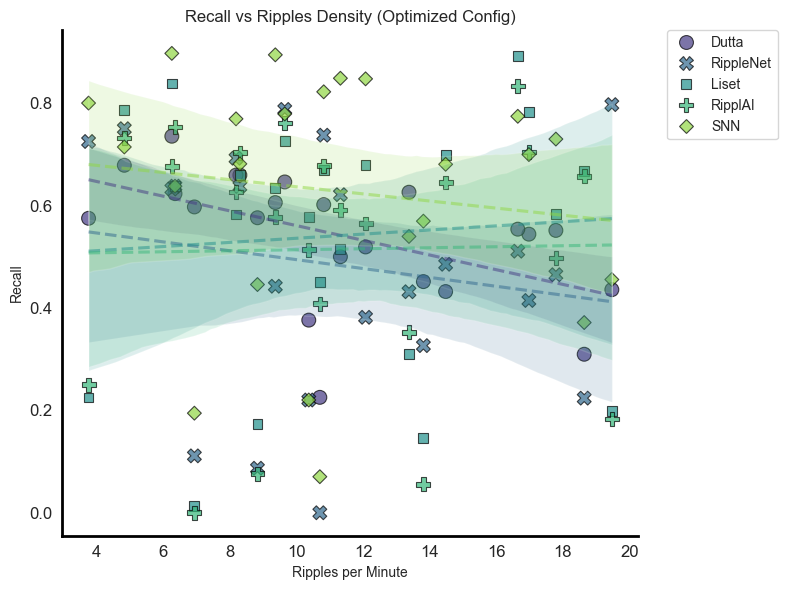

In [13]:
from scipy.stats import linregress
from scipy.stats import spearmanr

def plot_all_methods_ripples_vs_metric_opt(config_opt, metric="F1", sessions_reject=None, aggregate=True):
    """
    Plots Metric vs Ripples_per_min for all methods using their specific optimized threshold configuration.
    Features:
    - Colors by Method
    - Plots regression lines
    - Prints slopes and correlations
    """
    combined_data = []

    # 1. Process Data for all methods using process_config style logic
    for label, (df, threshold) in config_opt.items():
        # A. Filter sessions
        if sessions_reject is not None:
            df_subset = df[~df["Session"].isin(sessions_reject)].copy()
        else:
            df_subset = df.copy()

        # B. Identify threshold column
        if "Threshold" in df_subset.columns:
            col = "Threshold"
        elif "Adapt" in df_subset.columns:
            col = "Adapt"
        else:
            print(f"Skipping {label}: Column not found.")
            continue
            
        # C. Filter for specific threshold
        subset = df_subset[df_subset[col] == threshold].copy()
        subset["Ripples_per_min"]=subset["Num_Ripples"]/subset["Duration_min"]
        # D. Aggregate if requested (usually by Session/Channel to get one point per channel or session)
        # For this plot we usually want points per Session (mean/median over channels) or points per Channel
        # If we want "Ripples_per_min" on X, we need that column.
        
        # Let's aggregate to Session level to match "Ripples per minute" which is usually a session wide metric or channel specific?
        # Ripples_per_min is usually per channel? Or per session?
        # In the loaded dataframes, "Ripples_per_min" likely exists per row (Channel).
        
        if aggregate:
            # Group by Session to get one point per session (Median F1, Median Ripples Density)
            # This is safer for correlation if "Ripples_per_min" varies slightly or if we want session-level trend
            subset = subset.groupby(["Session"])[["Ripples_per_min", metric]].median().reset_index()
            
        if len(subset) > 0:
            subset["Method"] = label
            combined_data.append(subset)
        else:
            print(f"Warning: No data for {label} at {threshold}")

    if not combined_data:
        print("No data available.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    # 2. Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    
    methods = plot_df["Method"].unique()
    colors = sns.color_palette("viridis", len(methods))
    method_palette = dict(zip(methods, colors))
    
    # Scatter plot
    sns.scatterplot(x="Ripples_per_min", y=metric, hue="Method", style="Method",
                    data=plot_df, palette=method_palette, s=100, alpha=0.7, ax=ax, edgecolor="black")
    
    # helper for regression
    def plot_regression(data, color, label):
        x = data["Ripples_per_min"]
        y = data[metric]
        if len(x) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            # Plot line
            sns.regplot(x="Ripples_per_min", y=metric, data=data, scatter=False, 
                        color=color, ax=ax, line_kws={"linestyle": "--", "alpha": 0.5})
            return slope, r_value, p_value
        return None, None, None

    print(f"--- Statistics for {metric} vs Ripples/min ---")
    # Add regression lines + Spearman correlation
    for method in methods:
        subset = plot_df[plot_df["Method"] == method]
        slope, r, p = plot_regression(subset, method_palette[method], method)

        if len(subset) > 1:
            rho, p_s = spearmanr(subset["Ripples_per_min"], subset[metric])
        else:
            rho, p_s = None, None

        if slope is not None:
            if rho is not None:
                print(f"{method}: Slope={slope:.4f}, Pearson r={r:.3f}, p={p:.4f};  Spearman ρ={rho:.3f}, p={p_s:.4f}")
            else:
                print(f"{method}: Slope={slope:.4f}, Spearman ρ=NA, p=NA")
    
    
    ax.set_title(f"{metric} vs Ripples Density (Optimized Config)")
    ax.set_xlabel("Ripples per Minute")
    ax.set_ylabel(metric)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2)
    
    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()

# --- Run ---
if 'config_opt' in locals():
    # Use the config_opt dictionary which has (df, threshold) tuples

    # config_opt = {
    # "Dutta": (dutta_df, 7.0),
    # "RippleNet": (rippleNet_df, 0.8),
    # "Liset": (liset_df, 0.8), # Bad Recall
    # "RipplAI": (ripplAI_df[ripplAI_df['Model']=='LSTM'], 0.5), # Renamed key to match
    # # "SNN": (snn_df, 20)
    # "SNN": (snn_df, 20) # best performing network...
    # }
    
    plot_all_methods_ripples_vs_metric_opt(
        config_opt, 
        metric="F1", 
        sessions_reject=sessions_to_reject, 
        aggregate=aggregate
    )
    
    plot_all_methods_ripples_vs_metric_opt(
        config_opt, 
        metric="Precision", 
        sessions_reject=sessions_to_reject, 
        aggregate=aggregate
    )
    
    plot_all_methods_ripples_vs_metric_opt(
        config_opt, 
        metric="Recall", 
        sessions_reject=sessions_to_reject, 
        aggregate=aggregate
    )


--- Optimized vs Standard (Intra-Method) ---
Dutta: p=0.00029 (Opt > Std? Mean Diff: 0.036)
RippleNet: p=0.00006 (Opt > Std? Mean Diff: 0.059)
Liset: p=0.00009 (Opt > Std? Mean Diff: 0.185)
RipplAI: p=0.00074 (Opt > Std? Mean Diff: 0.077)
Error computing Wilcoxon for SNN: zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements.

--- SNN (Standard) vs Others (Standard) ---
vs Dutta: p=0.00128
vs RippleNet: p=0.00112
vs Liset: p=0.00146
vs RipplAI: p=0.09175

--- SNN (Optimized) vs Others (Optimized) ---
vs Dutta: p=0.00003
vs RippleNet: p=0.96431
vs Liset: p=0.08020
vs RipplAI: p=0.62207


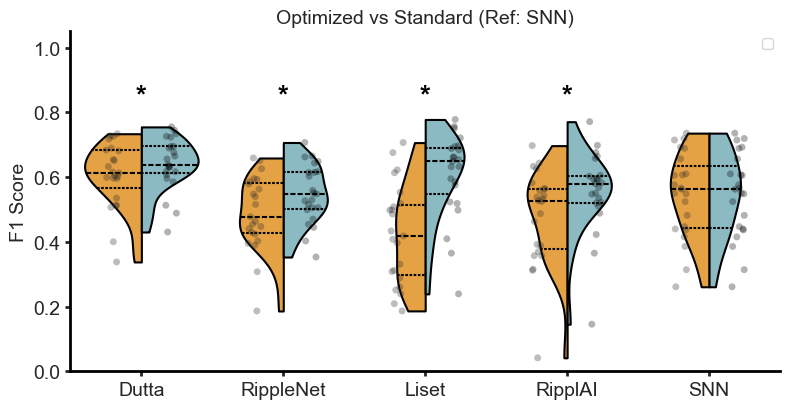

In [14]:
def get_best_per_session_df(df,metric="F1", optimize=["Threshold"], average_over=["Channel"],pick_best_row=True,verbose=False):
    """
    For each Session:
    - Optimizes over `optimize`
    - Averages over `average_over`
    - Optionally picks the single best row if duplicates remain
    """

    # Keep only columns that exist
    optimize = [c for c in optimize if c in df.columns]
    average_over = [c for c in average_over if c in df.columns]

    # 1. Aggregate metric to find best config
    # We group by Session + Optimization Params to find the best combo
    group_cols = ["Session"] + optimize
    agg_df = (
        df
        .groupby(group_cols)[metric]
        .median()
        .reset_index()
    )
    if verbose:
        print(f"After grouping by {group_cols}, {len(agg_df)} rows remain:")
        # display(agg_df.head())
        
    # 2. Best config per session
    best_cfg = (
        agg_df
        .sort_values(metric, ascending=False)
        .drop_duplicates(subset=["Session"])
    )
    if verbose:
        print(f"After selecting best config, {len(best_cfg)} rows remain:")
        display(best_cfg.head())
        
    # 3. Merge back to get original rows (channels) for that best config
    out = df.merge(best_cfg[group_cols], on=group_cols, how="inner")
    if verbose:
        print(f"After merging best configs, {len(out)} rows remain:")
        display(out)
        
    # 4. If multiple rows remain (e.g. channels), reduce to one row per session
    if pick_best_row:
        # Pick the single best channel/row
        out = (
            out
            .sort_values(metric, ascending=False)
            .drop_duplicates(subset=["Session"])
        )
    else:
        # Average over all available rows (channels) for that session
        # This collapses the Channel dimension
        group_cols = ["Session"] #+ average_over
        out = (
            out
            .groupby(group_cols)[["TP", "FP", "FN", "Precision", "Recall", "F1"]]
            .median()
            .reset_index()
        )
    if verbose:
        print(f"In the end, {len(out)} rows remain")
        display(out)
    return out


def plot_dynamic_vs_standard(config_opt_dfs, config_std, metric="F1", sessions_reject=None, optimize=["Threshold"], average_over=["Channel"], pick_best_row=True, reference_method="SNN",verbose=False):
    """
    Compares "Standard" (Fixed Threshold/Model) vs "Optimized" (Best Config Per Session).
    Includes statistical comparisons against a Reference Method (e.g. SNN).
    """
    combined_data = []
    
    # 1. Process Standard (Fixed)
    for label, (df, threshold) in config_std.items():
        if sessions_reject:
            df = df[~df["Session"].isin(sessions_reject)]
           
        thresh_col = "Threshold" if "Threshold" in df.columns else "Adapt"
        if thresh_col not in df.columns: continue

        subset = df[df[thresh_col] == threshold].copy()
        if not subset.empty:
            # Aggregate if needed to ensure one val per session/channel unit
            subset = subset.groupby(["Session", "Channel"])[metric].median().reset_index()
            subset["Method"] = label
            subset["Type"] = "Standard"
            combined_data.append(subset)
            
    # 2. Process Optimized (Dynamic per session)
    for label, df in config_opt_dfs.items():
        if sessions_reject:
            df = df[~df["Session"].isin(sessions_reject)]
            
        subset = get_best_per_session_df(df, metric=metric, optimize=optimize, average_over=average_over, pick_best_row=pick_best_row, verbose=verbose)
        
        if not subset.empty:
            subset["Method"] = label
            subset["Type"] = "Optimized"
            combined_data.append(subset)
            
    if not combined_data:
        print("No data.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 4.2))
    
    order = list(config_opt_dfs.keys())
    order = [o for o in order if o in plot_df["Method"].unique()]
    
    palette = {"Optimized": "#82C0CC", "Standard": "#FFA62B"}

    # Define hue_order to force Standard on left, Optimized on right
    hue_order = ["Standard", "Optimized"]

    sns.violinplot(x="Method", y=metric, hue="Type", data=plot_df, split=True, 
                   inner="quart", palette=palette, ax=ax, order=order, cut=0, 
                   linecolor='black', linewidth=1.5, hue_order=hue_order)
    
    sns.stripplot(x="Method", y=metric, hue="Type", data=plot_df, palette="dark:black", alpha=0.3, jitter=True, dodge=True, ax=ax, order=order, hue_order=hue_order)
    
    # --- Statistics ---
    
    # We aggregate to Session level for statistics to ensure paired samples match up
    # (Especially important if Optimized is 1 val/session and Standard is N vals/session)
    pivot = plot_df.pivot_table(index=["Session"], columns=["Method", "Type"], values=metric, aggfunc="median")
    
    max_val = plot_df[metric].max()
    
    # 1. Intra-Method (Optimized vs Standard) -> Annotated with Stars above violin
    print("\n--- Optimized vs Standard (Intra-Method) ---")
    for i, method in enumerate(order):
        
            if (method, "Optimized") in pivot.columns and (method, "Standard") in pivot.columns:
                v_opt = pivot[(method, "Optimized")].dropna()
                v_std = pivot[(method, "Standard")].dropna()
                
                common = v_opt.index.intersection(v_std.index)
                v_opt, v_std = v_opt.loc[common], v_std.loc[common]
                
                if len(v_opt) >= 3:
                    try:
                        s, p = wilcoxon(v_opt, v_std)
                    except ValueError as e:
                        print(f"Error computing Wilcoxon for {method}: {e}")
                        continue
                    print(f"{method}: p={p:.5f} (Opt > Std? Mean Diff: {v_opt.mean() - v_std.mean():.3f})")
                    if p < 0.05:
                        ax.text(i, max_val + 0.05, "*", ha='center', fontsize=20, color='black', fontweight='bold')
                    
    # 2. Inter-Method (Vs Reference) -> Annotated with Brackets
    if reference_method in order:
        ref_idx = order.index(reference_method)
        centers = range(len(order))
        
        # Start brackets higher than the individual stars
        current_h = max_val + 0.15 
        
        # We compare both types: Standard vs Standard, Optimized vs Optimized
        types_to_compare = ["Standard", "Optimized"]
        
        for type_label in types_to_compare:
            print(f"\n--- {reference_method} ({type_label}) vs Others ({type_label}) ---")
            
            if (reference_method, type_label) not in pivot.columns:
                print(f"Reference data for {reference_method} {type_label} not found.")
                continue
                
            ref_data = pivot[(reference_method, type_label)].dropna()
            
            for i, method in enumerate(order):
                if i == ref_idx: continue
                if (method, type_label) not in pivot.columns: continue
                
                comp_data = pivot[(method, type_label)].dropna()
                common = ref_data.index.intersection(comp_data.index)
                
                if len(common) >= 3:
                    s, p = wilcoxon(ref_data.loc[common], comp_data.loc[common])
                    print(f"vs {method}: p={p:.5f}")
                    
                    if p < 0.05:
                         
                        # barplot_annotate_brackets(ref_idx, i, p, centers, [current_h]*len(centers), ax, barh=0.01, maxasterix=3)
                        
                        # Add small text to indicate type (O=Optimized, S=Standard)
                        mid = (ref_idx + i) / 2
                        # label_char = "Opt" if type_label == "Optimized" else "Std"
                        # ax.text(mid, current_h + 0.04, label_char, ha='center', va='bottom', fontsize=8, color='gray')
                        
                        current_h += 0.09

    ax.set_ylim(0, 1.05 ) # Dynamic ylim to fit brackets
    ax.set_ylabel(f"{metric} Score", fontsize=14)
    ax.set_xlabel("")
    ax.legend("")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2.0)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=14, bottom=True, left=True, width=2.0)
    plt.title(f"Optimized vs Standard (Ref: {reference_method})", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Configuration ---

config_opt_dfs = {
    "Dutta": dutta_df,          
    "RippleNet": rippleNet_df,  
    "Liset": liset_df,          
    "RipplAI": ripplAI_df[ripplAI_df["Model"]=="LSTM"],     
    "SNN": snn_df[snn_df["Adapt"]==20]            
}

# config_std = {
#     "Dutta": (dutta_df, 4.0),
#     "RippleNet": (rippleNet_df, 0.7),
#     "Liset": (liset_df, 0.7),
#     "RipplAI": (ripplAI_df[ripplAI_df['Model']=='LSTM'], 0.4),   # Renamed key to match 
#     "SNN": (snn_df, 20)
# }

config_std_fixed = {
    "Dutta": (dutta_df, 6.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.3),
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='XGBOOST'], 0.6), # Renamed key to match
    "SNN": (snn_df, 20)
}

optimize=["Threshold"]
# optimize=["Threshold"]
average_over=["Channel"]
pick_best_row=False
# Run
if 'dutta_df' in locals():
    plot_dynamic_vs_standard(
        config_opt_dfs, 
        config_std_fixed, 
        metric="F1", 
        sessions_reject=sessions_to_reject, 
        optimize=optimize, 
        average_over=average_over, 
        pick_best_row=pick_best_row,
        reference_method="SNN", # Compare everything against SNN
        verbose=False
    )

In [15]:
def get_dynamic_summary_table(config_opt_dfs, config_std, sessions_reject=None, optimize=["Threshold"], average_over=["Channel"], pick_best_row=True, verbose=False):
    summary_data = []
    metrics = ["F1", "Precision", "Recall"]
    
    # 1. Standard (Fixed)
    # Average by Session/Channel
    for label, (df, threshold) in config_std.items():
        if sessions_reject:
            df = df[~df["Session"].isin(sessions_reject)]
            
        thresh_col = "Threshold" if "Threshold" in df.columns else "Adapt"
        if thresh_col not in df.columns: continue

        subset = df[df[thresh_col] == threshold].copy()
        
        if not subset.empty:
            row = {
                "Method": label,
                "Type": "Standard",
                "Threshold": str(threshold)
            }
            for m in metrics:
                if m in subset.columns:
                    row[m] = f"{subset[m].median():.2f} ± {subset[m].std():.2f}"
                else:
                    row[m] = "N/A"
            summary_data.append(row)

    # 2. Optimized (Dynamic)
    for label, df in config_opt_dfs.items():
        if sessions_reject:
            df = df[~df["Session"].isin(sessions_reject)]
            
        # Get best per session (Dynamic Optimization)
        # We reuse the helper function get_best_per_session_df from the previous cell
        subset = get_best_per_session_df(df, metric="F1", optimize=optimize, average_over=average_over, pick_best_row=pick_best_row, verbose=verbose)

        if not subset.empty:
            row = {
                "Method": label,
                "Type": "Optimized",
                "Threshold": "Opt_Session"
            }
            
            # Optional: Add mean threshold if it's numeric and the only optimization parameter for context
            if len(optimize) == 1 and optimize[0] in subset.columns:
                 if pd.api.types.is_numeric_dtype(subset[optimize[0]]):
                     mean_thresh = subset[optimize[0]].mean()
                     row["Threshold"] = f"Dynamic (Mean: {mean_thresh:.2f})"
                 
            for m in metrics:
                if m in subset.columns:
                    row[m] = f"{subset[m].median():.2f} ± {subset[m].std():.2f}"
                else:
                    row[m] = "N/A"
            summary_data.append(row)
            
    summary_df = pd.DataFrame(summary_data)
    # Sort for better readability (Method then Type)
    summary_df["Type"] = pd.Categorical(
        summary_df["Type"],
        categories=["Standard", "Optimized"],
        ordered=True
    )    
    return summary_df

# Run it using the configurations defined in the previous cell
if 'config_opt_dfs' in locals() and 'config_std_fixed' in locals():
    # optimize and average_over should be defined in the previous cell or we default them here
    opt_params = optimize if 'optimize' in locals() else ["Threshold"]
    avg_params = average_over if 'average_over' in locals() else ["Channel"]
    pick_best = pick_best_row if 'pick_best_row' in locals() else True
    
    summary_dynamic = get_dynamic_summary_table(config_opt_dfs, config_std_fixed, sessions_reject=sessions_to_reject, optimize=opt_params, average_over=avg_params, pick_best_row=pick_best, verbose=False)
    print("Dynamic (Best Per Session) vs Standard (Fixed) Performance Summary:")
    display(summary_dynamic)

Dynamic (Best Per Session) vs Standard (Fixed) Performance Summary:


,Method,Type,Threshold,F1,Precision,Recall
0,Dutta,Standard,6.0,0.61 ± 0.10,0.61 ± 0.17,0.66 ± 0.11
1,RippleNet,Standard,0.7,0.52 ± 0.17,0.53 ± 0.27,0.68 ± 0.26
2,Liset,Standard,0.3,0.42 ± 0.15,0.28 ± 0.17,0.89 ± 0.21
3,RipplAI,Standard,0.6,0.50 ± 0.15,0.41 ± 0.19,0.69 ± 0.20
4,SNN,Standard,20,0.57 ± 0.14,0.47 ± 0.16,0.87 ± 0.21
5,Dutta,Optimized,Opt_Session,0.64 ± 0.08,0.66 ± 0.11,0.64 ± 0.08
6,RippleNet,Optimized,Opt_Session,0.55 ± 0.09,0.54 ± 0.12,0.67 ± 0.13
7,Liset,Optimized,Opt_Session,0.65 ± 0.13,0.66 ± 0.15,0.62 ± 0.16
8,RipplAI,Optimized,Opt_Session,0.58 ± 0.13,0.57 ± 0.17,0.64 ± 0.15
9,SNN,Optimized,Opt_Session,0.56 ± 0.13,0.50 ± 0.16,0.89 ± 0.19
